In [3]:
import tensorflow as tf
import tensorflow.keras as keras
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

In [5]:

data = np.load(r"E:\Code\CAMZ\data\interim\boundingboxes_array.npy", allow_pickle=True)
rows_to_remove = [443, 474]
data = np.delete(data, rows_to_remove, axis=0)
mask = np.array([np.any(video == None) for video in data])
data = data[~mask]
data = data.astype(np.float32)
data.shape

(586, 300, 2)

In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models

input_shape = (300, 2)
bottleneck_steps = 32

inputs = layers.Input(shape=input_shape)

# Encoder
x = layers.LSTM(128, return_sequences=True, name = 'lstm1')(inputs)
x = layers.LSTM(64, return_sequences=True, name = 'lstm2')(x)
x = layers.LSTM(32, return_sequences=True, name = 'lstm3')(x)

# Downsample to (32, 64)
x = layers.Lambda(lambda t: t[:, ::(300 // bottleneck_steps), :], name = 'downsample')(x)

# Bottleneck
x = layers.LSTM(16, return_sequences=True, name = 'bottleneck')(x)

# Decoder
x = layers.LSTM(32, return_sequences=True, name = 'lstm5')(x)
x = layers.LSTM(64, return_sequences=True, name = 'lstm6')(x)
x = layers.UpSampling1D(size=(300 // bottleneck_steps), name = 'upsample')(x)
x = layers.LSTM(128, return_sequences=True,name = 'lstm7')(x)

# Crop to 300 exactly
x = layers.Cropping1D((0, x.shape[1] - 300),name='crop')(x)

# Output
outputs = layers.TimeDistributed(layers.Dense(2))(x)

model = models.Model(inputs, outputs)
model.compile(optimizer='adam', loss='mse')
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 300, 2)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm1 (LSTM)                    │ (None, 300, 128)       │        67,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm2 (LSTM)                    │ (None, 300, 64)        │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm3 (LSTM)                    │ (None, 300, 32)        │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ downsample (Lambda)             │ (None, 34, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (LSTM)               │ (None, 34, 16)         │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm5 (LSTM)                    │ (None, 34, 32)         │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm6 (LSTM)                    │ (None, 34, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ upsample (UpSampling1D)         │ (None, 306, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm7 (LSTM)                    │ (None, 306, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ crop (Cropping1D)               │ (None, 300, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 300, 2)         │           258 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 262,210 (1.00 MB)

 Trainable params: 262,210 (1.00 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, UpSampling1D
from tensorflow.keras.models import Model

input_seq = Input(shape=(300, 2))

# Encoder
x = Conv1D(128, kernel_size=3, activation='relu', padding='same',name = 'conv1')(input_seq)
x = MaxPooling1D(pool_size=5,name='maxpool1')(x) 

x = Conv1D(256, kernel_size=3, activation='relu', padding='same',name = 'conv2')(x)
x = MaxPooling1D(pool_size=2,name='maxpool2')(x) 

x = Conv1D(4, kernel_size=3, activation='relu', padding='same',name='conv3')(x)
x = MaxPooling1D(pool_size=2,name='bottleneck')(x) 

# Decoder
x = Conv1D(4, kernel_size=3, activation='relu', padding='same',name='conv4')(x)
x = UpSampling1D(size=2,name='up1')(x) 

x = Conv1D(256, kernel_size=3, activation='relu', padding='same',name='conv5')(x)
x = UpSampling1D(size=2,name='up2')(x)

x = Conv1D(128, kernel_size=3, activation='relu', padding='same',name='conv6')(x)
x = UpSampling1D(size=5,name='up3')(x)

# Output
output_seq = Conv1D(2, kernel_size=3, activation='linear', padding='same',name='conv7')(x)

model = Model(inputs=input_seq, outputs=output_seq)
model.compile(optimizer='adam', loss='mse')
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 300, 2)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 300, 128)       │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool1 (MaxPooling1D)         │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 60, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2 (MaxPooling1D)         │ (None, 30, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 30, 4)          │         3,076 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (MaxPooling1D)       │ (None, 15, 4)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv1D)                  │ (None, 15, 4)          │            52 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up1 (UpSampling1D)              │ (None, 30, 4)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv5 (Conv1D)                  │ (None, 30, 256)        │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up2 (UpSampling1D)              │ (None, 60, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv6 (Conv1D)                  │ (None, 60, 128)        │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up3 (UpSampling1D)              │ (None, 300, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv7 (Conv1D)                  │ (None, 300, 2)         │           770 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 205,114 (801.23 KB)

 Trainable params: 205,114 (801.23 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
from sklearn.model_selection import train_test_split


x_train, x_val = train_test_split(data, test_size=0.1, shuffle=True)

history = model.fit(
    x_train, x_train, 
    epochs=100,               
    batch_size=128,            
    shuffle=True,
    validation_data=(x_val, x_val)  
)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 212ms/step - loss: 0.3604 - val_loss: 0.0900
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - loss: 0.0884 - val_loss: 0.0554
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - loss: 0.0588 - val_loss: 0.0309
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - loss: 0.0335 - val_loss: 0.0322
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - loss: 0.0312 - val_loss: 0.0333
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - loss: 0.0300 - val_loss: 0.0280
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0285 - val_loss: 0.0252
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step - loss: 0.0260 - val_loss: 0.0244
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - loss: 0.0245 - val_loss: 0.0232
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - loss: 0.0242 - val_loss: 0.0227
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 0.0238 - val_loss: 0.0223
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step - loss: 0.02

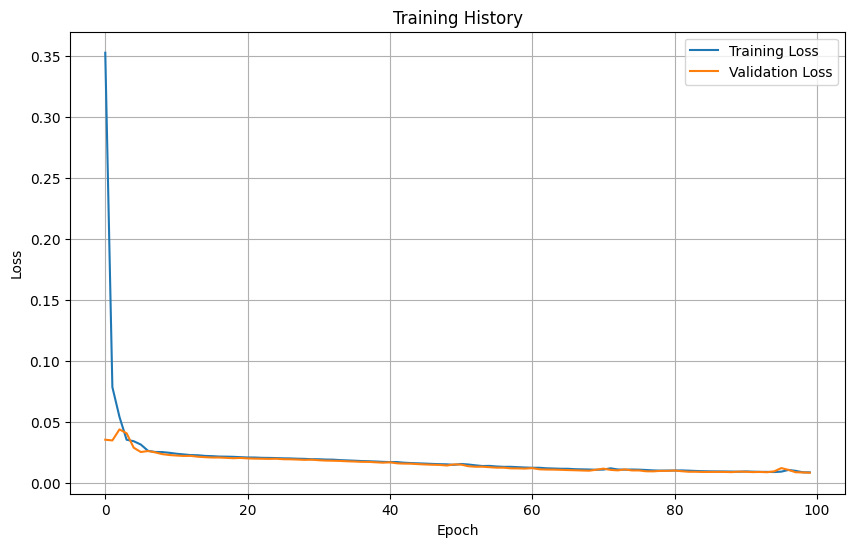

In [29]:
plt.figure(figsize=(10,6))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.title('Training History')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step
21


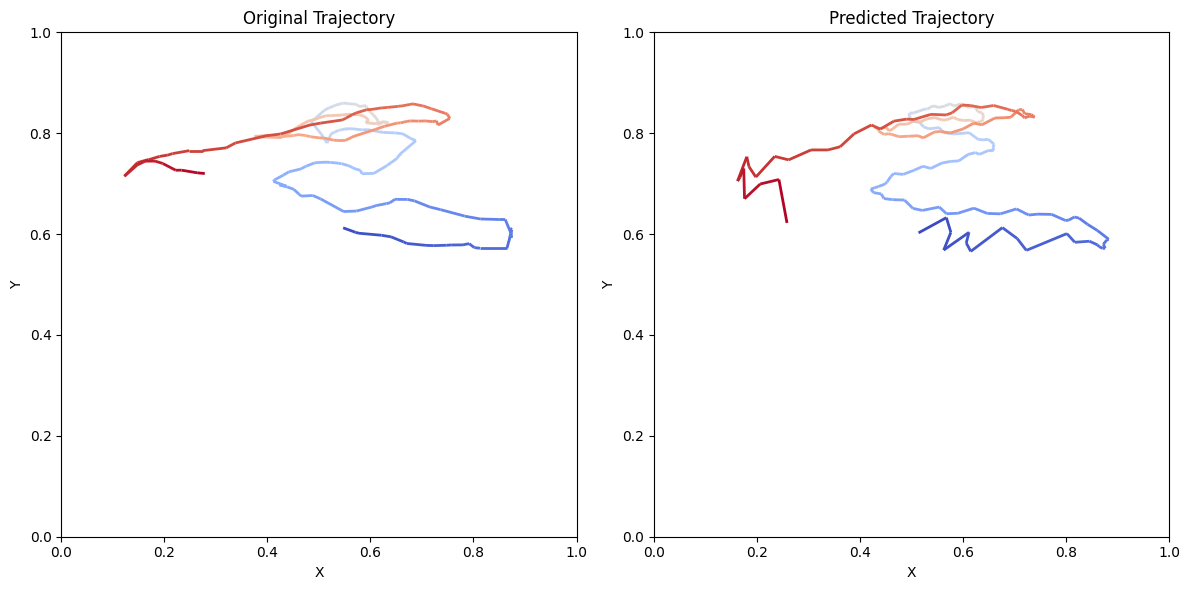

In [10]:
sample_idx = np.random.randint(x_val.shape[0])
sample = x_val[sample_idx]

predicted_trajectory = model.predict(np.expand_dims(sample, axis=0))  # Add batch dimension
predicted_trajectory = predicted_trajectory[0]  # Remove batch dimension for plotting
print(sample_idx)


# Function to plot trajectory with gradient
def plot_with_gradient(trajectory, ax, label):
    segments = []
    colors = []
    
    # Create line segments for the trajectory
    for i in range(len(trajectory) - 1):
        segment = [trajectory[i], trajectory[i + 1]]
        segments.append(segment)
        colors.append(i / len(trajectory))  # Normalize color
    
    # Create a LineCollection to apply the gradient
    lc = LineCollection(segments, cmap='coolwarm', array=np.array(colors), linewidth=2)
    ax.add_collection(lc)
    ax.autoscale()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(label)

# Plot the original trajectory with gradient
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

plot_with_gradient(sample, ax1, "Original Trajectory")
plot_with_gradient(predicted_trajectory, ax2, "Predicted Trajectory")

# Display the plots
plt.tight_layout()
plt.show()

In [11]:
encoder = Model(inputs=model.input, outputs=model.get_layer('bottleneck').output)

# Now the encoder will output the features at the bottleneck.
encoder.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 300, 2)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 300, 128)       │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool1 (MaxPooling1D)         │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 60, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2 (MaxPooling1D)         │ (None, 30, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 30, 4)          │         3,076 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (MaxPooling1D)       │ (None, 15, 4)          │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,532 (400.52 KB)

 Trainable params: 102,532 (400.52 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
encoder_pred = encoder.predict(data)
encoder_pred.shape

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


(586, 15, 4)

In [13]:
encoder_pred = encoder_pred.reshape(586,-1)
encoder_pred.shape

(586, 60)

In [14]:
X = encoder_pred

In [15]:
import pandas as pd
labels_df = pd.read_csv(r"E:\Code\CAMZ\data\interim\verdict.csv")  # Adjust delimiter if needed
print(labels_df.head())

verdict = labels_df['Verdict']
verdicts = verdict[~mask]
print(verdicts.shape)

   Name  Inactivity score  Time_bottom score  Time_top score  \
0  1L.1                 0                  1               1   
1  1L.2                 0                  1               1   
2  1L.3                 0                  1               1   
3  1L.4                 0                  1               1   
4  1L.5                 0                  0               1   

   Large_angle score  Small_angle score  Final Score  Verdict  
0                  1                  0         0.50        1  
1                  1                  0         0.50        1  
2                  1                  1         0.70        1  
3                  0                  1         0.50        1  
4                  1                  1         0.55        1  
(586,)


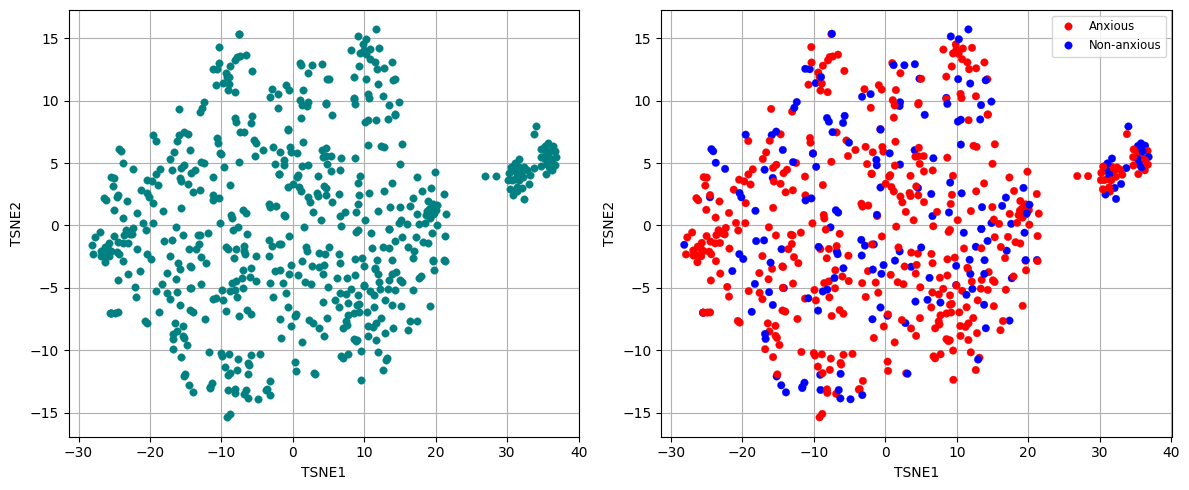

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

# Run t-SNE on X
tsne = TSNE(n_components=2, random_state=69, perplexity=30)
X_red = tsne.fit_transform(X)

# Map numeric verdicts to meaningful labels
label_map = {0: 'Non-anxious', 1: 'Anxious'}
verdict_labels = [label_map[int(v)] for v in verdicts]

# Create DataFrame
df = pd.DataFrame(X_red, columns=['TSNE1', 'TSNE2'])
df['Label'] = verdict_labels

# Custom color palette
palette = {'Non-anxious': 'blue', 'Anxious': 'red'}

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(data=df, x='TSNE1', y='TSNE2', ax=axes[0],
                color='teal', s=30, edgecolor=None, linewidth=0.2)
axes[0].grid(True)
axes[0].set_axisbelow(True)

sns.scatterplot(data=df, x='TSNE1', y='TSNE2', hue='Label', palette=palette,
                ax=axes[1], s=30, edgecolor=None, linewidth=0.2)
axes[1].legend(loc='best', fontsize='small')
axes[1].grid(True)
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.show()


C:\Users\HARSHU\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\HARSHU\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\HARSHU\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


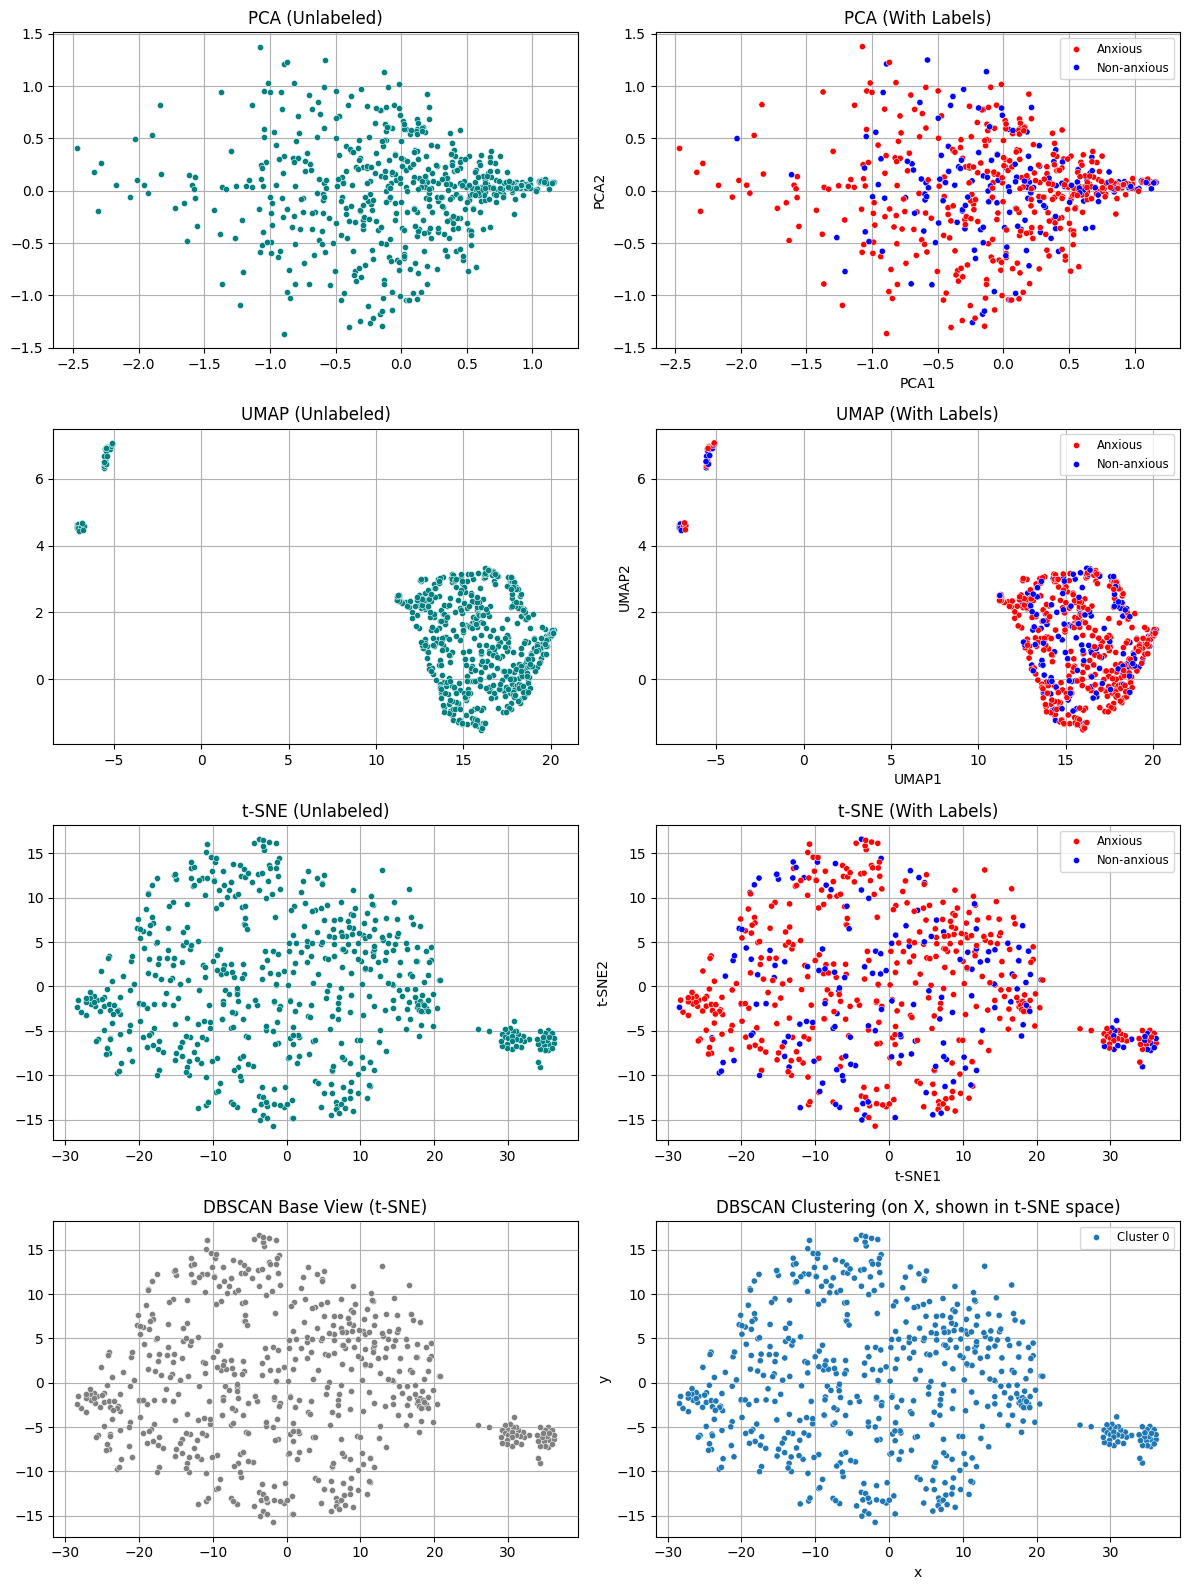

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap.umap_ as umap
from sklearn.cluster import DBSCAN
import pandas as pd

# Assume:
# X = high-dimensional data
# verdicts = binary labels (0 or 1)
label_names = {0: 'Non-anxious', 1: 'Anxious'}
label_colors = {'Non-anxious': 'blue', 'Anxious': 'red'}
labels_named = [label_names[v] for v in verdicts]

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# UMAP
umap_reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = umap_reducer.fit_transform(X)

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X)

# DBSCAN on original X
dbscan = DBSCAN(eps=5, min_samples=10)
db_labels = dbscan.fit_predict(X)
db_labels_named = ['Noise' if l == -1 else f'Cluster {l}' for l in db_labels]
unique_db_labels = sorted(set(db_labels_named))
db_palette = sns.color_palette("tab10", len(unique_db_labels))
db_color_map = {name: color for name, color in zip(unique_db_labels, db_palette)}

# Create figure with 4x2 grid
fig, axes = plt.subplots(4, 2, figsize=(12, 16))
methods = [('PCA', X_pca), ('UMAP', X_umap), ('t-SNE', X_tsne)]
for i, (name, reduced) in enumerate(methods):
    # Without labels
    sns.scatterplot(x=reduced[:, 0], y=reduced[:, 1], color='teal', s=20, ax=axes[i, 0])
    axes[i, 0].set_title(f'{name} (Unlabeled)')
    axes[i, 0].grid(True)
    axes[i, 0].set_axisbelow(True)

    # With labels
    df = pd.DataFrame({f'{name}1': reduced[:, 0], f'{name}2': reduced[:, 1], 'Label': labels_named})
    sns.scatterplot(data=df, x=f'{name}1', y=f'{name}2', hue='Label', palette=label_colors, ax=axes[i, 1], s=20)
    axes[i, 1].set_title(f'{name} (With Labels)')
    axes[i, 1].legend(loc='best', fontsize='small')
    axes[i, 1].grid(True)
    axes[i, 1].set_axisbelow(True)

# DBSCAN comparison
# Without cluster labels
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], color='gray', s=20, ax=axes[3, 0])
axes[3, 0].set_title("DBSCAN Base View (t-SNE)")
axes[3, 0].grid(True)
axes[3, 0].set_axisbelow(True)

# With DBSCAN cluster labels
df_db = pd.DataFrame({'x': X_tsne[:, 0], 'y': X_tsne[:, 1], 'Cluster': db_labels_named})
sns.scatterplot(data=df_db, x='x', y='y', hue='Cluster', palette=db_color_map, ax=axes[3, 1], s=20)
axes[3, 1].set_title("DBSCAN Clustering (on X, shown in t-SNE space)")
axes[3, 1].legend(loc='best', fontsize='small')
axes[3, 1].grid(True)
axes[3, 1].set_axisbelow(True)

plt.tight_layout()
plt.show()
